In [26]:
from measure_diversity.embeddings.SBERT import encode_sentences
from measure_diversity.measure import mean_pairwise_distance, distance_dispersion, cluster_inertia_diversity, convex_hull_volume
import os

In [27]:
def read_sentences_from_txt(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


In [34]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("")))
DATA_PATH_high = os.path.join(BASE_DIR, "Diversity-Measurement/pilot_datasets/semantic_diversity/qqp_high_diversity.txt")
DATA_PATH_low = os.path.join(BASE_DIR, "Diversity-Measurement/pilot_datasets/semantic_diversity/qqp_low_diversity.txt")

In [35]:
sentences_high = read_sentences_from_txt(DATA_PATH_high)
print(f"Loaded {len(sentences_high)} sentences.")
print(sentences_high[:3])

sentences_low = read_sentences_from_txt(DATA_PATH_low)
print(f"Loaded {len(sentences_low)} sentences.")
print(sentences_low[:3])

Loaded 400 sentences.
['How do I to score good marks in 12th boards?', 'What are some good virtual assistant bots?', 'What is physical quantities and also its types?']
Loaded 400 sentences.
['How do I to score good marks in 12th boards?', 'How can we score excellent marks in class 12th board exams?', 'What is physical quantities and also its types?']


In [36]:
embeddings_high = encode_sentences(sentences_high)
print(f"Embedding shape: {len(embeddings_high)} x {len(embeddings_high[0])}")

embeddings_low = encode_sentences(sentences_low)
print(f"Embedding shape: {len(embeddings_low)} x {len(embeddings_low[0])}")


Embedding shape: 400 x 384
Embedding shape: 400 x 384


In [37]:
print("High Diversity:")
print("Mean Pairwise Distance:", mean_pairwise_distance(embeddings_high))
print("Distance Dispersion:", distance_dispersion(embeddings_high))
print("Cluster Inertia Diversity:", cluster_inertia_diversity(embeddings_high))
try:
    print("Convex Hull Volume:", convex_hull_volume(embeddings_high))
except Exception as e:
    print("Convex Hull Volume: error -", e)

print("\nLow Diversity:")
print("Mean Pairwise Distance:", mean_pairwise_distance(embeddings_low))
print("Distance Dispersion:", distance_dispersion(embeddings_low))
print("Cluster Inertia Diversity:", cluster_inertia_diversity(embeddings_low))
try:
    print("Convex Hull Volume:", convex_hull_volume(embeddings_low))
except Exception as e:
    print("Convex Hull Volume: error -", e)


High Diversity:
Mean Pairwise Distance: 0.9582518268414513
Distance Dispersion: 76468.49578194781
Cluster Inertia Diversity: 344.67299943741705


/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Convex Hull Volume: 0.0

Low Diversity:
Mean Pairwise Distance: 0.9455451291757477
Distance Dispersion: 75454.50130822467
Cluster Inertia Diversity: 322.90224146609455


/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Convex Hull Volume: 0.0


In [38]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


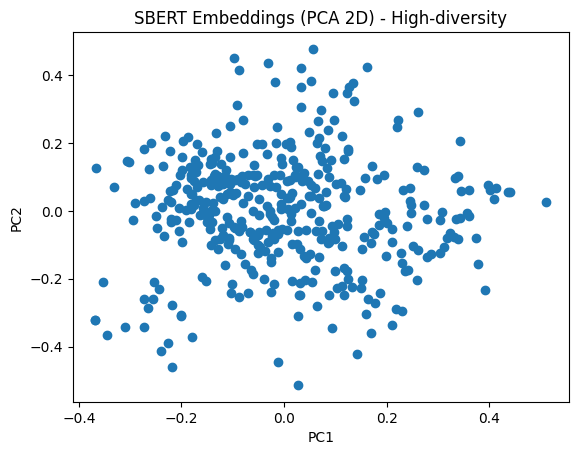

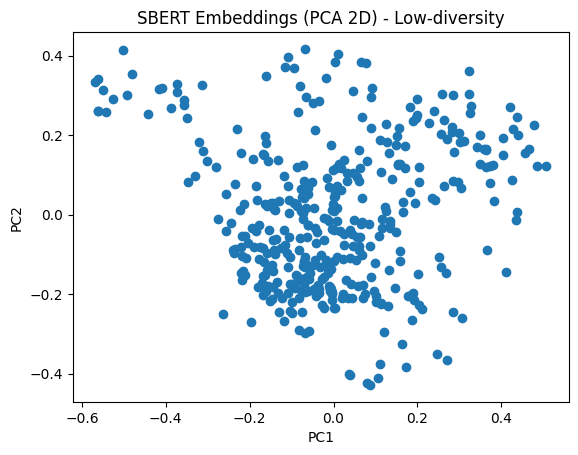

In [39]:
pca = PCA(n_components=2)
embeddings_2d_high = pca.fit_transform(embeddings_high)
plt.scatter(embeddings_2d_high[:,0], embeddings_2d_high[:,1])
plt.title("SBERT Embeddings (PCA 2D) - High-diversity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pca = PCA(n_components=2)
embeddings_2d_low = pca.fit_transform(embeddings_low)
plt.scatter(embeddings_2d_low[:,0], embeddings_2d_low[:,1])
plt.title("SBERT Embeddings (PCA 2D) - Low-diversity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


